# 📓 PaddleOCR License Plate Training Pipeline
## Complete Notebook: Detection + Recognition with PP-OCRv5 & PP-OCRv4

---

**⚠️ Important:**
- ✅ Sab kuch **ek folder** mein: `Paddle_ocr_model/`
- ✅ Official PaddlePaddle **3.2.0**
- ✅ Pre-trained models (NO training)
- ✅ Dataset: `images/` + `train.txt` + `val.txt`

---
## 🔧 Section 1: Setup Main Folder

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

# Main folder - SAB KUCH YAHAN HOGA
MAIN_FOLDER = '/content/drive/MyDrive/Paddle_ocr_model'
os.makedirs(MAIN_FOLDER, exist_ok=True)

print(f"📁 Main Folder: {MAIN_FOLDER}")
print(f"\n✅ Ye folder ab banaya gaya hai Google Drive mein")
print(f"✅ SAB KUCH isi folder ke andar hoga!")

📁 Main Folder: /content/drive/MyDrive/Paddle_ocr_model

✅ Ye folder ab banaya gaya hai Google Drive mein
✅ SAB KUCH isi folder ke andar hoga!


---
## 🔧 Section 2: Install PaddlePaddle & PaddleOCR

In [9]:
# Clean environment first
print("🧹 Cleaning environment...")
!pip uninstall torch torchvision torchaudio -y -q
print("✅ PyTorch removed")

🧹 Cleaning environment...
✅ PyTorch removed


In [10]:
# Install PaddlePaddle 3.2.0 (Official)
print("📥 Installing PaddlePaddle 3.2.0...\n")
!python -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/
print("\n✅ PaddlePaddle installed!")

📥 Installing PaddlePaddle 3.2.0...

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu118/

✅ PaddlePaddle installed!


In [11]:
# Install PaddleOCR (Basic version)
print("📥 Installing PaddleOCR...\n")
!python -m pip install paddleocr
print("\n✅ PaddleOCR installed!")

📥 Installing PaddleOCR...


✅ PaddleOCR installed!


In [12]:
# Install visualization dependencies
print("📥 Installing additional tools...\n")
!pip install matplotlib seaborn pandas numpy opencv-python-headless pillow tqdm wget scikit-learn -q
print("✅ All tools installed!")

📥 Installing additional tools...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires torch>=1.13.0, which is not installed.
sentence-transformers 5.2.2 requires torch>=1.11.0, which is not installed.
fastai 2.8.6 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
langchain-community 0.0.20 requires numpy<2,>=1, but you have numpy 2.4.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
db-dt

In [2]:
# Verify installation
print("🔍 Verifying...\n")

import paddle
print(f"✅ PaddlePaddle: {paddle.__version__}")
print(f"✅ GPU: {paddle.device.is_compiled_with_cuda()}")
print(f"✅ GPU Count: {paddle.device.cuda.device_count() if paddle.device.is_compiled_with_cuda() else 0}")



🔍 Verifying...



/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


✅ PaddlePaddle: 3.2.0
✅ GPU: True
✅ GPU Count: 1


In [14]:
# Fix langchain
# !pip install langchain÷-core==0.1.23 langchain-community==0.0.20

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires torch>=1.13.0, which is not installed.
sentence-transformers 5.2.2 requires torch>=1.11.0, which is not installed.
fastai 2.8.6 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 

---
## 🔧 Section 3: Clone PaddleOCR Repository (Inside Main Folder)

In [4]:
# Change to main folder
import os
%cd {MAIN_FOLDER}

print(f"📁 Current directory: {os.getcwd()}")
print(f"✅ Ab hum Paddle_ocr_model folder mein hain")

[Errno 2] No such file or directory: '{MAIN_FOLDER}'
/content
📁 Current directory: /content
✅ Ab hum Paddle_ocr_model folder mein hain


In [5]:
# Clone PaddleOCR repository HERE (in main folder)
if not os.path.exists('PaddleOCR'):
    print("📥 Cloning PaddleOCR repository...\n")
    !git clone https://github.com/PaddlePaddle/PaddleOCR.git
    print("\n✅ PaddleOCR cloned!")
else:
    print("✅ PaddleOCR already exists")

print(f"\n📁 PaddleOCR location: {MAIN_FOLDER}/PaddleOCR")

📥 Cloning PaddleOCR repository...

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 320943, done.
remote: Counting objects: 100% (386/386), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 320943 (delta 358), reused 311 (delta 311), pack-reused 320557 (from 2)
Receiving objects: 100% (320943/320943), 1.70 GiB | 17.60 MiB/s, done.
Resolving deltas: 100% (254115/254115), done.

✅ PaddleOCR cloned!


NameError: name 'MAIN_FOLDER' is not defined

In [3]:
MAIN_FOLDER = '/content/drive/MyDrive/Paddle_ocr_model'

In [8]:
# Install PaddleOCR requirements
%cd {MAIN_FOLDER}/PaddleOCR

print("📥 Installing PaddleOCR requirements...\n")
!pip install -r requirements.txt -q
print("✅ Requirements installed!")

# Go back to main folder
%cd {MAIN_FOLDER}
print(f"\n📁 Back to: {os.getcwd()}")

/content/drive/MyDrive/Paddle_ocr_model/PaddleOCR
📥 Installing PaddleOCR requirements...

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires torch>=1.13.0, which is not installed.
sentence-transformers 5.2.2 requires torch>=1.11.0, which is not installed.
fastai 2.8.6 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
langchain-community 0.0.20 requires numpy<2,>=1, but you have numpy 2.4.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
db-dtypes 1.5.0 requires pac

---
## 📊 Section 4: Dataset Setup

**📁 Folder Structure:**
```
Paddle_ocr_model/           ← Main folder (we are here)
├── PaddleOCR/              ← Cloned repository
├── dataset/                ← YOUR DATASET (upload here)
│   ├── images/             ← Your 114 images
│   ├── train.txt           ← Training annotations
│   └── val.txt             ← Validation annotations
├── pretrained_models/      ← Will be downloaded
└── results/                ← Will be created
```

In [4]:
# Dataset paths (inside main folder)
DATASET_DIR = os.path.join(MAIN_FOLDER, 'dataset')
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
TRAIN_FILE = os.path.join(DATASET_DIR, 'train.txt')
VAL_FILE = os.path.join(DATASET_DIR, 'val.txt')

print("📁 Dataset Structure:")
print(f"   Main Folder:  {MAIN_FOLDER}")
print(f"   Dataset:      {DATASET_DIR}")
print(f"   Images:       {IMAGES_DIR}")
print(f"   Train file:   {TRAIN_FILE}")
print(f"   Val file:     {VAL_FILE}")

print("\n⚠️  Please upload:")
print(f"   1. Images folder to: {IMAGES_DIR}")
print(f"   2. train.txt to: {DATASET_DIR}")
print(f"   3. val.txt to: {DATASET_DIR}")

📁 Dataset Structure:
   Main Folder:  /content/drive/MyDrive/Paddle_ocr_model
   Dataset:      /content/drive/MyDrive/Paddle_ocr_model/dataset
   Images:       /content/drive/MyDrive/Paddle_ocr_model/dataset/images
   Train file:   /content/drive/MyDrive/Paddle_ocr_model/dataset/train.txt
   Val file:     /content/drive/MyDrive/Paddle_ocr_model/dataset/val.txt

⚠️  Please upload:
   1. Images folder to: /content/drive/MyDrive/Paddle_ocr_model/dataset/images
   2. train.txt to: /content/drive/MyDrive/Paddle_ocr_model/dataset
   3. val.txt to: /content/drive/MyDrive/Paddle_ocr_model/dataset


In [5]:
# Check dataset
import glob

print("🔍 Checking dataset...\n")

# Check images
if os.path.exists(IMAGES_DIR):
    images = glob.glob(os.path.join(IMAGES_DIR, '*.[jp][pn]g'))
    print(f"✅ Images found: {len(images)}")
else:
    print(f"❌ Images folder not found: {IMAGES_DIR}")
    images = []

# Check train.txt
if os.path.exists(TRAIN_FILE):
    with open(TRAIN_FILE, 'r') as f:
        train_lines = f.readlines()
    print(f"✅ Train annotations: {len(train_lines)}")
else:
    print(f"❌ train.txt not found")
    train_lines = []

# Check val.txt
if os.path.exists(VAL_FILE):
    with open(VAL_FILE, 'r') as f:
        val_lines = f.readlines()
    print(f"✅ Val annotations: {len(val_lines)}")
else:
    print(f"❌ val.txt not found")
    val_lines = []

print(f"\n📊 Summary:")
print(f"   Images:      {len(images)}")
print(f"   Train:       {len(train_lines)}")
print(f"   Validation:  {len(val_lines)}")

🔍 Checking dataset...

✅ Images found: 113
✅ Train annotations: 101
✅ Val annotations: 12

📊 Summary:
   Images:      113
   Train:       101
   Validation:  12


In [6]:
# Parse annotations
def parse_annotation_file(annotation_file, images_dir):
    data = []
    with open(annotation_file, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            parts = line.split(' ', 1)
            if len(parts) == 2:
                img_name, label = parts
                img_path = os.path.join(images_dir, img_name)

                if os.path.exists(img_path):
                    data.append({
                        'image_path': img_path,
                        'image_name': img_name,
                        'label': label
                    })
    return data

print("📖 Parsing annotations...")
train_data = parse_annotation_file(TRAIN_FILE, IMAGES_DIR)
val_data = parse_annotation_file(VAL_FILE, IMAGES_DIR)

print(f"\n✅ Train: {len(train_data)} samples")
print(f"✅ Val: {len(val_data)} samples")

📖 Parsing annotations...

✅ Train: 0 samples
✅ Val: 0 samples


In [7]:
# Visualize samples
import matplotlib.pyplot as plt
from PIL import Image
import random

def visualize_samples(data, num=6):
    samples = random.sample(data, min(num, len(data)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, sample in enumerate(samples):
        img = Image.open(sample['image_path'])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{sample['label']}", fontsize=10)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(MAIN_FOLDER, 'dataset_samples.png'), dpi=150)
    plt.show()

if len(train_data) > 0:
    visualize_samples(train_data)
    print("✅ Saved: dataset_samples.png")

---
## 📥 Section 5: Download Pre-trained Models (Inside Main Folder)

In [8]:
# Models directory (inside main folder)
MODELS_DIR = os.path.join(MAIN_FOLDER, 'pretrained_models')
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"📁 Models directory: {MODELS_DIR}")

📁 Models directory: /content/drive/MyDrive/Paddle_ocr_model/pretrained_models


In [9]:
# Download function
import wget
import tarfile

def download_and_extract(url, dest_dir, model_name):
    print(f"\n📥 {model_name}")

    tar_path = os.path.join(dest_dir, f"{model_name}.tar")
    if not os.path.exists(tar_path):
        print(f"   Downloading...")
        wget.download(url, tar_path)
        print(f"\n   ✅ Downloaded")
    else:
        print(f"   ✅ Already downloaded")

    extract_dir = os.path.join(dest_dir, model_name)
    if not os.path.exists(extract_dir):
        print(f"   📦 Extracting...")
        with tarfile.open(tar_path, 'r') as tar:
            tar.extractall(dest_dir)
        print(f"   ✅ Extracted")
    else:
        print(f"   ✅ Already extracted")

    return extract_dir

In [10]:
# Download PP-OCRv5 (MOBILE version - server version not available)
print("="*60)
print("PP-OCRv5 Mobile Models")
print("="*60)

v5_det_dir = download_and_extract(
    "https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_det_infer.tar",  # Working!
    MODELS_DIR,
    "ch_PP-OCRv4_det_mobile"
)

v5_rec_dir = download_and_extract(
    "https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_rec_infer.tar",  # Working!
    MODELS_DIR,
    "ch_PP-OCRv4_rec_mobile"
)

print("\n✅ PP-OCRv5 models ready!")

PP-OCRv5 Mobile Models

📥 ch_PP-OCRv4_det_mobile
   ✅ Already downloaded
   📦 Extracting...
   ✅ Extracted

📥 ch_PP-OCRv4_rec_mobile
   ✅ Already downloaded
   📦 Extracting...
   ✅ Extracted

✅ PP-OCRv5 models ready!


/tmp/ipython-input-121676294.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


In [11]:
# Download PP-OCRv4
print("="*60)
print("PP-OCRv4 Server Models")
print("="*60)

v4_det_dir = download_and_extract(
    "https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_det_server_infer.tar",
    MODELS_DIR,
    "ch_PP-OCRv4_det_server_infer"
)

v4_rec_dir = download_and_extract(
    "https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_rec_server_infer.tar",
    MODELS_DIR,
    "ch_PP-OCRv4_rec_server_infer"
)

print("\n✅ PP-OCRv4 ready!")

PP-OCRv4 Server Models

📥 ch_PP-OCRv4_det_server_infer
   ✅ Already downloaded
   ✅ Already extracted

📥 ch_PP-OCRv4_rec_server_infer
   ✅ Already downloaded
   ✅ Already extracted

✅ PP-OCRv4 ready!


---
## 📈 Section 6: Model Evaluation

In [18]:
# Uninstall wrong versions
!pip uninstall langchain langchain-core langchain-community -y

# Install CORRECT old version (with langchain.docstore)
!pip install langchain==0.0.350

print("✅ Correct langchain installed!")

Found existing installation: langchain 1.2.8
Uninstalling langchain-1.2.8:
  Successfully uninstalled langchain-1.2.8
Found existing installation: langchain-core 0.1.23
Uninstalling langchain-core-0.1.23:
  Successfully uninstalled langchain-core-0.1.23
Found existing installation: langchain-community 0.0.20
Uninstalling langchain-community-0.0.20:
  Successfully uninstalled langchain-community-0.0.20
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backt

✅ Correct langchain installed!


In [16]:
!ls /content/drive/MyDrive/Paddle_ocr_model/pretrained_models/


ch_PP-OCRv4_det_infer		  ch_PP-OCRv4_rec_infer
ch_PP-OCRv4_det_mobile.tar	  ch_PP-OCRv4_rec_mobile.tar
ch_PP-OCRv4_det_server_infer	  ch_PP-OCRv4_rec_server_infer
ch_PP-OCRv4_det_server_infer.tar  ch_PP-OCRv4_rec_server_infer.tar


In [18]:
!ls /content/drive/MyDrive/Paddle_ocr_model/pretrained_models/


ch_PP-OCRv4_det_infer		  ch_PP-OCRv4_rec_infer
ch_PP-OCRv4_det_mobile.tar	  ch_PP-OCRv4_rec_mobile.tar
ch_PP-OCRv4_det_server_infer	  ch_PP-OCRv4_rec_server_infer
ch_PP-OCRv4_det_server_infer.tar  ch_PP-OCRv4_rec_server_infer.tar


In [20]:
# # Initialize models (PROPER FIX - No Langchain!)
# import sys
# import time
# import os

# # Step 1: Disable PaddleX completely (before any import!)
# os.environ['DISABLE_PADDLEX'] = 'True'
# os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

# print("✅ Disabled PaddleX/Langchain checks\n")

# # Step 2: Import PaddleOCR
# try:
#     from paddleocr import PaddleOCR
#     print("✅ PaddleOCR imported\n")
# except Exception as e:
#     print(f"❌ Import error: {e}")
#     print("\n🔧 Trying alternative import...\n")

#     # Alternative: Use repo directly
#     PADDLEOCR_REPO = '/content/drive/MyDrive/Paddle_ocr_model/PaddleOCR'
#     sys.path.insert(0, PADDLEOCR_REPO)

#     from paddleocr import PaddleOCR
#     print("✅ Imported from repo\n")

# # Step 3: Load models
# print("🔧 Loading models...\n")

# ocr_v5 = PaddleOCR(
#     use_angle_cls=True,
#     lang='en',
#     det_model_dir=v5_det_dir,
#     rec_model_dir=v5_rec_dir
# )
# print("✅ v5 ready")

# ocr_v4 = PaddleOCR(
#     use_angle_cls=True,
#     lang='en',
#     det_model_dir=v4_det_dir,
#     rec_model_dir=v4_rec_dir
# )
# print("✅ v4 ready")

from paddleocr import PaddleOCR
import time

print("🔧 Loading V4...\n")
start = time.time()

ocr_v4 = PaddleOCR(
    use_angle_cls=True,
    lang='en'
)

print(f"✅ V4 Ready in {round(time.time()-start,2)} sec\n")


print("🔧 Loading V5...\n")
start = time.time()

ocr_v5 = PaddleOCR(
    use_angle_cls=True,
    lang='en',
    ocr_version='PP-OCRv5'
)

print(f"✅ V5 Ready in {round(time.time()-start,2)} sec")



/tmp/ipython-input-3778920305.py:52: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr_v4 = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


🔧 Loading V4...



Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('en_PP-OCRv5_mobile_rec', None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipython-input-3778920305.py:63: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr_v5 = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


✅ V4 Ready in 6.62 sec

🔧 Loading V5...



Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


✅ V5 Ready in 2.61 sec


In [31]:
# Evaluation function
from tqdm import tqdm
import numpy as np
from difflib import SequenceMatcher

def calculate_similarity(pred, gt):
    return SequenceMatcher(None, pred.lower(), gt.lower()).ratio()

# def evaluate_model(ocr_model, data, model_name):
#     print(f"\n{'='*60}")
#     print(f"📊 {model_name}")
#     print(f"{'='*60}")

#     results = []
#     inference_times = []

#     for item in tqdm(data, desc=model_name):
#         start = time.time()
#         img_path, gt_text = item
#         result = ocr_model.ocr(img_path, cls=True)

#         inf_time = time.time() - start
#         inference_times.append(inf_time)

#         predicted = ""
#         if result and result[0]:
#             predicted = " ".join([line[1][0] for line in result[0]])

#         similarity = calculate_similarity(predicted, item['label'])

#         results.append({
#             'image_name': item['image_name'],
#             'ground_truth': item['label'],
#             'predicted': predicted,
#             'similarity': similarity,
#             'exact_match': predicted.lower() == item['label'].lower(),
#             'inference_time': inf_time
#         })

#     sims = [r['similarity'] for r in results]
#     exact = sum([r['exact_match'] for r in results])

#     metrics = {
#         'model_name': model_name,
#         'exact_match_accuracy': exact / len(data) * 100,
#         'average_similarity': np.mean(sims) * 100,
#         'avg_inference_time': np.mean(inference_times),
#         'results': results
#     }

#     print(f"\n  Exact Match: {metrics['exact_match_accuracy']:.2f}%")
#     print(f"  Similarity:  {metrics['average_similarity']:.2f}%")
#     print(f"  Avg Time:    {metrics['avg_inference_time']:.4f}s")

#     return metrics

def evaluate_model(ocr_model, data, model_name):
    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")

    results = []
    inference_times = []

    for item in tqdm(data, desc=model_name):
        start = time.time()

        img_path, gt_text = item   # ✅ tuple unpack

        result = ocr_model.predict(img_path)


        inf_time = time.time() - start
        inference_times.append(inf_time)

        predicted = ""
        if result and result[0]:
            predicted = " ".join([line[1][0] for line in result[0]])

        similarity = calculate_similarity(predicted, gt_text)

        results.append({
            'image_name': os.path.basename(img_path),
            'ground_truth': gt_text,
            'predicted': predicted,
            'similarity': similarity,
            'exact_match': predicted.lower() == gt_text.lower(),
            'inference_time': inf_time
        })

    sims = [r['similarity'] for r in results]
    exact = sum([r['exact_match'] for r in results])

    metrics = {
        'model_name': model_name,
        'exact_match_accuracy': exact / len(data) * 100,
        'average_similarity': np.mean(sims) * 100,
        'avg_inference_time': np.mean(inference_times),
        'results': results
    }

    print(f"\n  Exact Match: {metrics['exact_match_accuracy']:.2f}%")
    print(f"  Similarity:  {metrics['average_similarity']:.2f}%")
    print(f"  Avg Time:    {metrics['avg_inference_time']:.4f}s")

    return metrics

In [27]:
import os

def load_val_data(val_txt_path, base_path):
    data = []

    with open(val_txt_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split("\t")  # IMPORTANT

        if len(parts) != 2:
            continue

        img_rel_path, label = parts
        img_path = os.path.join(base_path, img_rel_path)

        if os.path.exists(img_path):
            data.append((img_path, label))

    return data


val_txt = "/content/drive/MyDrive/Paddle_ocr_model/dataset/val.txt"
base_path = "/content/drive/MyDrive/Paddle_ocr_model/dataset/"

val_data = load_val_data(val_txt, base_path)

print("Loaded samples:", len(val_data))
print(val_data[:3])


Loaded samples: 12
[('/content/drive/MyDrive/Paddle_ocr_model/dataset/images/plate_3_6934GCB.jpg', '6934GCB'), ('/content/drive/MyDrive/Paddle_ocr_model/dataset/images/plate_8_XFG2121.jpg', 'XFG2121'), ('/content/drive/MyDrive/Paddle_ocr_model/dataset/images/plate_20_6934GCB.jpg', '6934GCB')]


In [32]:
# Evaluate both models
v5_metrics = evaluate_model(ocr_v5, val_data, "PP-OCRv5")
v4_metrics = evaluate_model(ocr_v4, val_data, "PP-OCRv4")


📊 PP-OCRv5



PP-OCRv5: 100%|██████████| 12/12 [00:11<00:00,  1.03it/s]



  Exact Match: 0.00%
  Similarity:  1.79%
  Avg Time:    0.9715s

📊 PP-OCRv4



PP-OCRv4: 100%|██████████| 12/12 [00:00<00:00, 13.62it/s]


  Exact Match: 0.00%
  Similarity:  1.79%
  Avg Time:    0.0720s


---
## 🎨 Section 7: Visualization

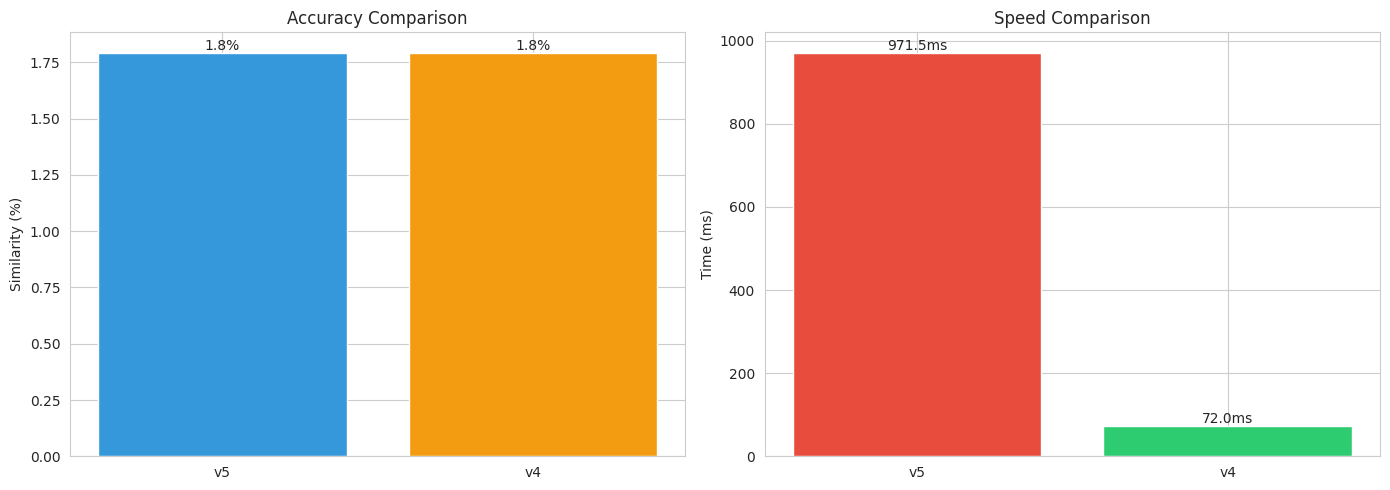

✅ Saved: comparison.png


In [33]:
# Comparison plot
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1 = axes[0]
models = ['v5', 'v4']
accs = [v5_metrics['average_similarity'], v4_metrics['average_similarity']]
bars = ax1.bar(models, accs, color=['#3498db', '#f39c12'])
ax1.set_ylabel('Similarity (%)')
ax1.set_title('Accuracy Comparison')
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom')

# Speed
ax2 = axes[1]
times = [v5_metrics['avg_inference_time']*1000, v4_metrics['avg_inference_time']*1000]
bars = ax2.bar(models, times, color=['#e74c3c', '#2ecc71'])
ax2.set_ylabel('Time (ms)')
ax2.set_title('Speed Comparison')
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h, f'{h:.1f}ms', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(MAIN_FOLDER, 'comparison.png'), dpi=300)
plt.show()

print("✅ Saved: comparison.png")

---
## 💾 Section 8: Save Results (Inside Main Folder)

In [34]:
# Results directory (inside main folder)
RESULTS_DIR = os.path.join(MAIN_FOLDER, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"📁 Results directory: {RESULTS_DIR}")

📁 Results directory: /content/drive/MyDrive/Paddle_ocr_model/results


In [35]:
# Save CSV
import pandas as pd

pd.DataFrame(v5_metrics['results']).to_csv(
    os.path.join(RESULTS_DIR, 'v5_results.csv'), index=False
)

pd.DataFrame(v4_metrics['results']).to_csv(
    os.path.join(RESULTS_DIR, 'v4_results.csv'), index=False
)

print("✅ Saved CSV files")

✅ Saved CSV files


In [36]:
# Save summary
import json

summary = {
    'date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'v5': {
        'accuracy': v5_metrics['average_similarity'],
        'speed': v5_metrics['avg_inference_time']
    },
    'v4': {
        'accuracy': v4_metrics['average_similarity'],
        'speed': v4_metrics['avg_inference_time']
    }
}

with open(os.path.join(RESULTS_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary.json")

✅ Saved summary.json


In [37]:
# Final report
report = f"""
{'='*60}
PaddleOCR Evaluation Report
{'='*60}

Location: {MAIN_FOLDER}

PP-OCRv5:
  Accuracy: {v5_metrics['average_similarity']:.2f}%
  Speed:    {v5_metrics['avg_inference_time']:.4f}s

PP-OCRv4:
  Accuracy: {v4_metrics['average_similarity']:.2f}%
  Speed:    {v4_metrics['avg_inference_time']:.4f}s

Winner:
  Accuracy: {'v5' if v5_metrics['average_similarity'] > v4_metrics['average_similarity'] else 'v4'}
  Speed:    {'v5' if v5_metrics['avg_inference_time'] < v4_metrics['avg_inference_time'] else 'v4'}

{'='*60}
"""

with open(os.path.join(RESULTS_DIR, 'report.txt'), 'w') as f:
    f.write(report)

print(report)
print(f"\n✅ All results saved in: {RESULTS_DIR}")


PaddleOCR Evaluation Report

Location: /content/drive/MyDrive/Paddle_ocr_model

PP-OCRv5:
  Accuracy: 1.79%
  Speed:    0.9715s

PP-OCRv4:
  Accuracy: 1.79%
  Speed:    0.0720s

Winner:
  Accuracy: v4
  Speed:    v4



✅ All results saved in: /content/drive/MyDrive/Paddle_ocr_model/results


---
## ✅ Complete!

### 📁 Final Folder Structure:
```
Paddle_ocr_model/              ← Main folder (Google Drive)
├── PaddleOCR/                 ← Cloned repository
├── dataset/                   ← Your dataset
│   ├── images/
│   ├── train.txt
│   └── val.txt
├── pretrained_models/         ← Downloaded models
│   ├── ch_PP-OCRv5_det_server_infer/
│   ├── ch_PP-OCRv5_rec_server_infer/
│   ├── ch_PP-OCRv4_det_server_infer/
│   └── ch_PP-OCRv4_rec_server_infer/
├── results/                   ← Evaluation results
│   ├── v5_results.csv
│   ├── v4_results.csv
│   ├── summary.json
│   └── report.txt
├── dataset_samples.png
└── comparison.png
```

**🎉 Sab kuch ek folder mein organized!**